# End-to-End NLP Pipeline for Customer Feedback Intelligence and Sentiment-Driven Decision Support



In [1]:
# Install libraries required by the assignment.
# In Google Colab this cell normally takes 1–3 minutes.
%pip -q install -U nltk spacy wordcloud sentence-transformers transformers accelerate

# Download the English spaCy pipeline used for lemmatisation and NER.
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os
import re
import html
import time
import json
import random
import warnings
import zipfile
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('/content/nlp_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
MODEL_DIR = OUTPUT_DIR / 'models'
for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Output folder:', OUTPUT_DIR)
print('Random seed:', SEED)

Output folder: /content/nlp_outputs
Random seed: 42


## 1. Load the exact supplied dataset

Upload either:

- the downloaded ZIP archive containing `Tweets.csv`, **or**
- `Tweets.csv` directly.

The cell automatically finds/extracts the file. In a local Jupyter environment, set `DATA_PATH` manually instead.

In [4]:
# Colab upload helper: accepts either the ZIP archive or Tweets.csv directly.
try:
    from google.colab import files
    uploaded = files.upload()
    uploaded_names = list(uploaded.keys())
    print('Uploaded:', uploaded_names)
except ImportError:
    uploaded_names = []
    print('Not running in Colab. Set DATA_PATH manually below if needed.')

DATA_PATH = None

# 1) Direct CSV upload
for name in uploaded_names:
    if Path(name).name.lower() == 'tweets.csv':
        DATA_PATH = Path('/content') / name
        break

# 2) ZIP upload containing Tweets.csv
if DATA_PATH is None:
    for name in uploaded_names:
        if name.lower().endswith('.zip'):
            zip_path = Path('/content') / name
            extract_dir = Path('/content/airline_dataset')
            extract_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(extract_dir)
            matches = list(extract_dir.rglob('Tweets.csv'))
            if matches:
                DATA_PATH = matches[0]
                break

# 3) Common paths if the file already exists in the Colab session
if DATA_PATH is None:
    candidates = [Path('/content/Tweets.csv'), Path('/content/airline_dataset/Tweets.csv')]
    for candidate in candidates:
        if candidate.exists():
            DATA_PATH = candidate
            break

if DATA_PATH is None:
    raise FileNotFoundError('Tweets.csv was not found. Upload the ZIP archive or Tweets.csv and rerun this cell.')

print('Using dataset:', DATA_PATH)

Saving archive (4).zip to archive (4) (1).zip
Uploaded: ['archive (4) (1).zip']
Using dataset: /content/airline_dataset/Tweets.csv


In [5]:
# Load and audit the dataset
raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()

required_cols = {'text', 'airline_sentiment', 'airline', 'negativereason'}
missing_required = required_cols.difference(df.columns)
if missing_required:
    raise ValueError(f'Missing required columns: {sorted(missing_required)}')

print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst five rows:')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)
display(missing_table)

print('\nDuplicate full rows:', int(df.duplicated().sum()))
print('Duplicate tweet_id values:', int(df['tweet_id'].duplicated().sum()) if 'tweet_id' in df.columns else 'N/A')
print('\nSentiment distribution:')
display(df['airline_sentiment'].value_counts().to_frame('count'))

missing_table.to_csv(TABLE_DIR / 'dataset_missingness.csv')
df['airline_sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count').to_csv(
    TABLE_DIR / 'sentiment_counts.csv', index=False
)

Dataset shape: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

First five rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Data types:


,dtype
tweet_id,int64
airline_sentiment,object
airline_sentiment_confidence,float64
negativereason,object
negativereason_confidence,float64
airline,object
airline_sentiment_gold,object
name,object
negativereason_gold,object
retweet_count,int64



Missing values:


,missing_count,missing_percent
negativereason_gold,14608,99.78
airline_sentiment_gold,14600,99.73
tweet_coord,13621,93.04
negativereason,5462,37.31
user_timezone,4820,32.92
tweet_location,4733,32.33
negativereason_confidence,4118,28.13
airline,0,0.00
tweet_id,0,0.00
airline_sentiment,0,0.00



Duplicate full rows: 36
Duplicate tweet_id values: 155

Sentiment distribution:


,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


# Task 1 — Preprocessing and Exploratory Analysis

Task 1 requires NLTK and spaCy preprocessing, including tokenisation, lemmatisation, stop-word handling, basic cleaning and a spaCy NER pass. It also requires exploratory visualisations and a comparison of the two preprocessing approaches.

## 1.1 Basic text cleaning

The cleaning stage removes URLs and user mentions, retains hashtag words, decodes HTML, lowercases text and normalises whitespace. It deliberately does **not** remove sentiment labels or use any metadata that could leak the target.

In [6]:
# Basic cleaning used before NLTK/spaCy processing
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
SPACE_RE = re.compile(r'\s+')


def basic_clean_text(text):
    text = '' if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = text.replace('#', ' ')          # keep hashtag word, remove # symbol
    text = text.lower()
    text = SPACE_RE.sub(' ', text).strip()
    return text


df['text_basic'] = df['text'].map(basic_clean_text)
df['raw_char_length'] = df['text'].astype(str).str.len()
df['raw_word_length'] = df['text_basic'].str.split().str.len()

display(df[['text', 'text_basic', 'airline_sentiment']].head(8))

,text,text_basic,airline_sentiment
0,@VirginAmerica What @dhepburn said.,what said.,neutral
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,positive
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take ano...,neutral
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",negative
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,negative
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $30 a flight for seats tha...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time i fly vx this “ear worm...",positive
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...,neutral


## 1.2 NLTK preprocessing

NLTK is used for tokenisation, POS-aware WordNet lemmatisation and stop-word handling. Negation terms are explicitly retained because they are important for sentiment classification.

In [8]:
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import nltk.pathsec
nltk.pathsec.ALLOW_PROXIED_FETCH = True

# Newer NLTK releases may use the *_eng / punkt_tab resources; downloading both is harmless.
for resource in [
    'punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'
]:
    try:
        nltk.download(resource, quiet=True)
    except Exception as exc:
        print(f'Warning while downloading {resource}: {exc}')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
NEGATIONS = {'no', 'nor', 'not', "n't", 'never'}
stop_words_no_negation = stop_words.difference(NEGATIONS)


def treebank_to_wordnet(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('N'):
        return wordnet.NOUN
    if tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN


def nltk_preprocess(text):
    tokens = word_tokenize(text)
    # Retain alphabetic tokens plus contraction negation token n\'t.
    lexical_tokens = [t for t in tokens if t.isalpha() or t == "n't"]
    tagged = pos_tag(lexical_tokens) if lexical_tokens else []
    lemmas_all = [lemmatizer.lemmatize(tok, treebank_to_wordnet(tag)) for tok, tag in tagged]
    lemmas_filtered = [tok for tok in lemmas_all if tok not in stop_words_no_negation and len(tok) > 1]
    return lemmas_all, lemmas_filtered


start = time.perf_counter()
nltk_results = df['text_basic'].map(nltk_preprocess)
df['nltk_lemmas_all'] = nltk_results.map(lambda x: ' '.join(x[0]))
df['nltk_processed'] = nltk_results.map(lambda x: ' '.join(x[1]))
nltk_seconds = time.perf_counter() - start

print(f'NLTK preprocessing time: {nltk_seconds:.2f} seconds')
display(df[['text_basic', 'nltk_lemmas_all', 'nltk_processed']].head(8))

NLTK preprocessing time: 19.01 seconds


,text_basic,nltk_lemmas_all,nltk_processed
0,what said.,what say,say
1,plus you've added commercials to the experienc...,plus you add commercial to the experience tacky,plus add commercial experience tacky
2,i didn't today... must mean i need to take ano...,i do n't today must mean i need to take anothe...,n't today must mean need take another trip
3,"it's really aggressive to blast obnoxious ""ent...",it really aggressive to blast obnoxious entert...,really aggressive blast obnoxious entertainmen...
4,and it's a really big bad thing about it,and it a really big bad thing about it,really big bad thing
5,seriously would pay $30 a flight for seats tha...,seriously would pay a flight for seat that do ...,seriously would pay flight seat n't playing re...
6,"yes, nearly every time i fly vx this “ear worm...",yes nearly every time i fly vx this ear worm w...,yes nearly every time fly vx ear worm win go away
7,really missed a prime opportunity for men with...,really miss a prime opportunity for men withou...,really miss prime opportunity men without hat ...


## 1.3 spaCy preprocessing, Named Entity Recognition and service-term matching

spaCy performs tokenisation, contextual lemmatisation and NER in one pipeline. Standard entity labels such as `ORG`, `GPE`, `DATE`, `MONEY` and `PRODUCT` are retained. A small `PhraseMatcher` also identifies service-related concepts that a general NER model may not label as named entities.

In [9]:
import spacy
from spacy.matcher import PhraseMatcher

nlp = spacy.load('en_core_web_sm', disable=['parser'])

SERVICE_TERMS = [
    'flight', 'late flight', 'delay', 'delayed', 'cancellation', 'cancelled flight',
    'baggage', 'bag', 'luggage', 'booking', 'reservation', 'refund', 'customer service',
    'gate', 'seat', 'crew', 'website', 'app', 'check in', 'boarding', 'ticket'
]
matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
matcher.add('SERVICE_TERM', [nlp.make_doc(term) for term in SERVICE_TERMS])

spacy_processed = []
entity_records = []
service_term_records = []
spacy_lemma_examples = []

start = time.perf_counter()
for row_idx, doc in zip(df.index, nlp.pipe(df['text_basic'].tolist(), batch_size=128)):
    lemmas = []
    all_lemmas = []
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        lemma = token.lemma_.lower().strip()
        if not lemma:
            continue
        all_lemmas.append(lemma)
        if (not token.is_stop or lemma in NEGATIONS) and (token.is_alpha or lemma == "n't") and len(lemma) > 1:
            lemmas.append(lemma)
    spacy_processed.append(' '.join(lemmas))

    for ent in doc.ents:
        entity_records.append({
            'row_index': row_idx,
            'entity': ent.text,
            'label': ent.label_,
            'sentiment': df.at[row_idx, 'airline_sentiment'],
            'airline': df.at[row_idx, 'airline']
        })

    for match_id, start_i, end_i in matcher(doc):
        service_term_records.append({
            'row_index': row_idx,
            'service_term': doc[start_i:end_i].text.lower(),
            'sentiment': df.at[row_idx, 'airline_sentiment']
        })

spacy_seconds = time.perf_counter() - start
df['spacy_processed'] = spacy_processed
entities_df = pd.DataFrame(entity_records)
service_terms_df = pd.DataFrame(service_term_records)

print(f'spaCy preprocessing + NER time: {spacy_seconds:.2f} seconds')
display(df[['text_basic', 'spacy_processed']].head(8))

print('\nNER examples:')
if not entities_df.empty:
    display(entities_df.head(20))
else:
    print('No named entities detected.')

print('\nService-term examples:')
if not service_terms_df.empty:
    display(service_terms_df.head(20))
else:
    print('No service terms detected.')

entities_df.to_csv(TABLE_DIR / 'spacy_entities.csv', index=False)
service_terms_df.to_csv(TABLE_DIR / 'service_terms.csv', index=False)

spaCy preprocessing + NER time: 35.39 seconds


,text_basic,spacy_processed
0,what said.,say
1,plus you've added commercials to the experienc...,plus add commercial experience tacky
2,i didn't today... must mean i need to take ano...,today mean need trip
3,"it's really aggressive to blast obnoxious ""ent...",aggressive blast obnoxious entertainment guest...
4,and it's a really big bad thing about it,big bad thing
5,seriously would pay $30 a flight for seats tha...,seriously pay flight seat playing bad thing fl...
6,"yes, nearly every time i fly vx this “ear worm...",yes nearly time fly vx ear worm will away
7,really missed a prime opportunity for men with...,miss prime opportunity man hat parody



NER examples:


,row_index,entity,label,sentiment,airline
0,2,today,DATE,neutral,Virgin America
1,5,30,MONEY,negative,Virgin America
2,5,va,GPE,negative,Virgin America
3,10,second,ORDINAL,neutral,Virgin America
4,10,10-24,TIME,neutral,Virgin America
5,12,my 1st,DATE,positive,Virgin America
6,16,first,ORDINAL,positive,Virgin America
7,16,29daystogo,CARDINAL,positive,Virgin America
8,17,sfo,ORG,negative,Virgin America
9,17,last week,DATE,negative,Virgin America



Service-term examples:


,row_index,service_term,sentiment
0,5,flight,negative
1,16,flight,positive
2,17,seat,negative
3,24,seat,negative
4,29,seat,neutral
5,30,flight,negative
6,30,booking,negative
7,32,flight,negative
8,32,seat,negative
9,38,flight,neutral


## 1.4 NLTK vs spaCy comparison

The table below compares the two pipelines on the full dataset. The intent is not to declare one library universally superior, but to show practical differences relevant to an end-to-end customer-feedback system.

In [10]:
# Full-dataset token/vocabulary statistics
def corpus_stats(series):
    token_lists = series.fillna('').str.split()
    total_tokens = int(token_lists.map(len).sum())
    vocab = set()
    for toks in token_lists:
        vocab.update(toks)
    return total_tokens, len(vocab)

nltk_tokens, nltk_vocab = corpus_stats(df['nltk_processed'])
spacy_tokens, spacy_vocab = corpus_stats(df['spacy_processed'])

sample_idx = df['text_basic'].str.len().idxmax() if len(df) else 0
sample_text = df.loc[sample_idx, 'text_basic']
nltk_sample = df.loc[sample_idx, 'nltk_processed']
spacy_sample = df.loc[sample_idx, 'spacy_processed']
entity_example = 'None detected'
if not entities_df.empty:
    entity_example = '; '.join(
        (entities_df['entity'].astype(str) + ' (' + entities_df['label'].astype(str) + ')').head(5).tolist()
    )

comparison_table = pd.DataFrame({
    'Criterion': [
        'Total retained tokens', 'Vocabulary size', 'Processing time (seconds)',
        'Example processed output', 'Named entity support in this notebook',
        'Practical implication'
    ],
    'NLTK': [
        nltk_tokens, nltk_vocab, round(nltk_seconds, 2), nltk_sample[:220],
        'Not used for NER in this pipeline',
        'Transparent modular pipeline; useful for explicit token/POS/WordNet experiments.'
    ],
    'spaCy': [
        spacy_tokens, spacy_vocab, round(spacy_seconds, 2), spacy_sample[:220],
        entity_example,
        'Integrated tokenisation, contextual lemmatisation and NER; efficient for production-style pipelines.'
    ]
})

display(comparison_table)
comparison_table.to_csv(TABLE_DIR / 'nltk_vs_spacy_comparison.csv', index=False)

print('\nExample source text:')
print(sample_text)

,Criterion,NLTK,spaCy
0,Total retained tokens,126292,110896
1,Vocabulary size,9042,8836
2,Processing time (seconds),19.01,35.39
3,Example processed output,eyyyy cancel flightlations flight book problem...,eyyyy cancel flightlation flight booking probl...
4,Named entity support in this notebook,Not used for NER in this pipeline,today (DATE); 30 (MONEY); va (GPE); second (OR...
5,Practical implication,Transparent modular pipeline; useful for expli...,"Integrated tokenisation, contextual lemmatisat..."



Example source text:
eyyyy! cancelled flightlations, flight booking problemss, reflight booking problemss, but y'all got me on the same flight out tonight (not tomorrow) & the fc upgrade. thx!


## 1.5 Exploratory visualisations

Each figure is saved automatically in `/content/nlp_outputs/figures/` at 300 dpi so it can be inserted directly into the report.

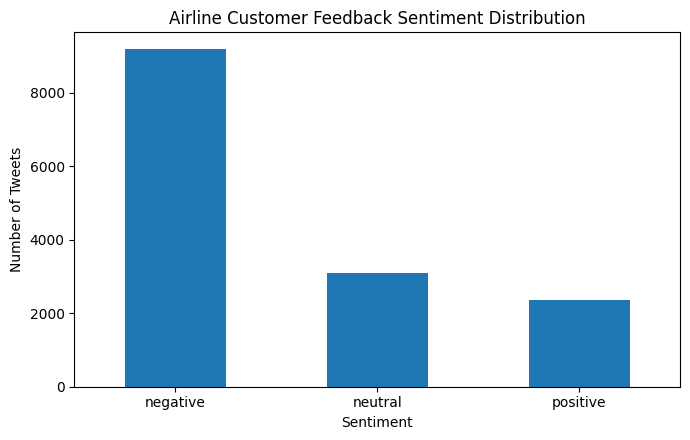

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [11]:
# Figure 1 — Sentiment/class distribution
sentiment_counts = df['airline_sentiment'].value_counts().reindex(['negative', 'neutral', 'positive'])

plt.figure(figsize=(7, 4.5))
sentiment_counts.plot(kind='bar')
plt.title('Airline Customer Feedback Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

display(sentiment_counts.to_frame('count'))

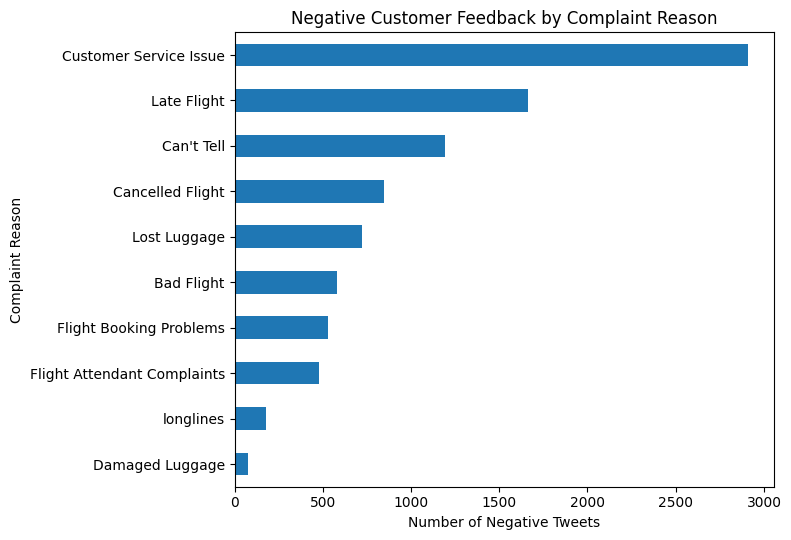

,count
negativereason,
Customer Service Issue,2910
Late Flight,1665
Can't Tell,1190
Cancelled Flight,847
Lost Luggage,724
Bad Flight,580
Flight Booking Problems,529
Flight Attendant Complaints,481
longlines,178


In [12]:
# Figure 2 — Most common negative complaint reasons
negative_reason_counts = (
    df.loc[df['airline_sentiment'].eq('negative'), 'negativereason']
      .dropna()
      .value_counts()
      .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5.5))
negative_reason_counts.plot(kind='barh')
plt.title('Negative Customer Feedback by Complaint Reason')
plt.xlabel('Number of Negative Tweets')
plt.ylabel('Complaint Reason')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_negative_reasons.png', dpi=300, bbox_inches='tight')
plt.show()

display(negative_reason_counts.sort_values(ascending=False).to_frame('count'))

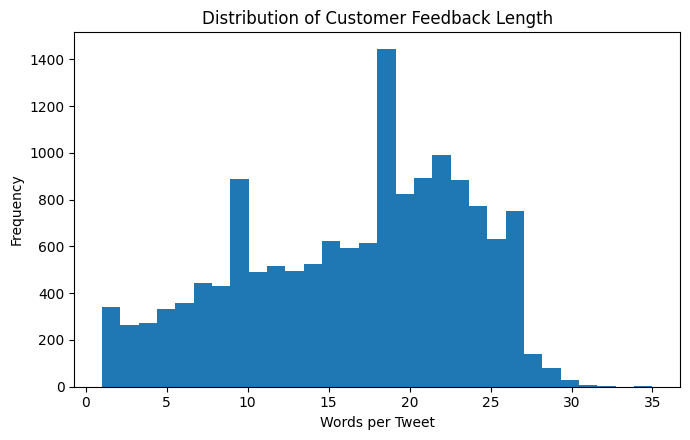

,count,mean,median,std
airline_sentiment,,,,
negative,9178,18.57,20.0,5.98
neutral,3099,13.19,12.0,7.01
positive,2363,12.85,13.0,7.06


In [13]:
# Figure 3 — Review/tweet length distribution
plt.figure(figsize=(7, 4.5))
plt.hist(df['raw_word_length'].dropna(), bins=30)
plt.title('Distribution of Customer Feedback Length')
plt.xlabel('Words per Tweet')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_review_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

display(df.groupby('airline_sentiment')['raw_word_length'].agg(['count', 'mean', 'median', 'std']).round(2))

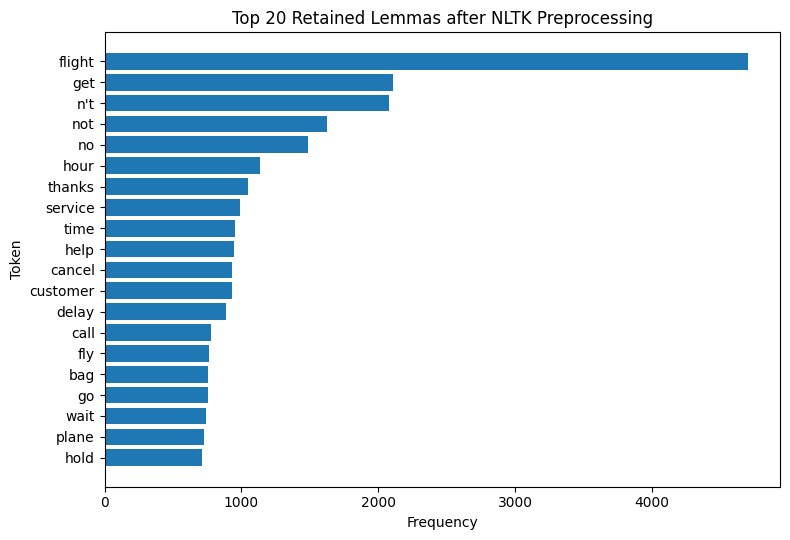

,token,count
0,flight,4701
1,get,2109
2,n't,2077
3,not,1626
4,no,1487
5,hour,1138
6,thanks,1050
7,service,993
8,time,951
9,help,946


In [14]:
# Figure 4 — Top retained NLTK lemmas
all_tokens = [tok for text in df['nltk_processed'].fillna('') for tok in text.split()]
top_tokens = pd.DataFrame(Counter(all_tokens).most_common(20), columns=['token', 'count'])

top_tokens_plot = top_tokens.sort_values('count', ascending=True)
plt.figure(figsize=(8, 5.5))
plt.barh(top_tokens_plot['token'], top_tokens_plot['count'])
plt.title('Top 20 Retained Lemmas after NLTK Preprocessing')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_top_tokens.png', dpi=300, bbox_inches='tight')
plt.show()

display(top_tokens)
top_tokens.to_csv(TABLE_DIR / 'top_tokens.csv', index=False)

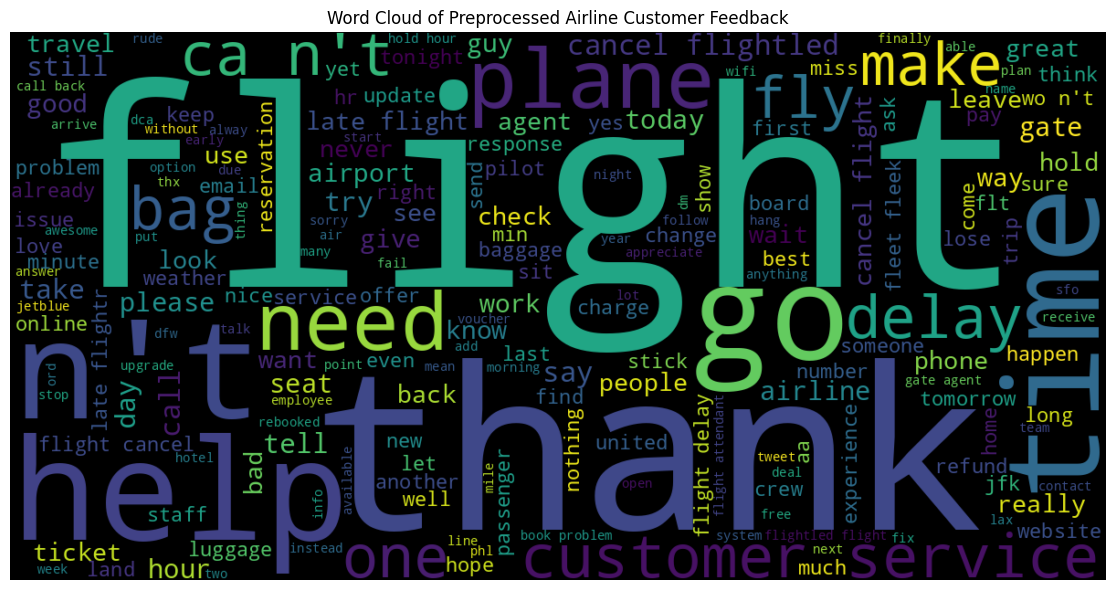

In [15]:
# Figure 5 — Word cloud (descriptive only; frequency chart above should be the main quantitative evidence)
from wordcloud import WordCloud

corpus_text = ' '.join(df['nltk_processed'].fillna('').tolist())
wc = WordCloud(width=1200, height=600, random_state=SEED).generate(corpus_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Preprocessed Airline Customer Feedback')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

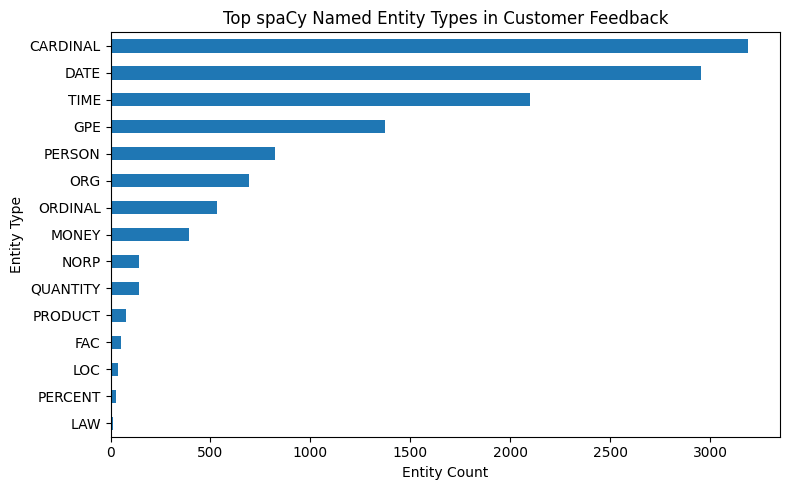

,count
label,
CARDINAL,3190
DATE,2952
TIME,2098
GPE,1373
PERSON,821
ORG,694
ORDINAL,531
MONEY,391
NORP,143


In [16]:
# Figure 6 — Named entity type frequency
if not entities_df.empty:
    entity_type_counts = entities_df['label'].value_counts().head(15).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    entity_type_counts.plot(kind='barh')
    plt.title('Top spaCy Named Entity Types in Customer Feedback')
    plt.xlabel('Entity Count')
    plt.ylabel('Entity Type')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'task1_entity_type_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()
    display(entity_type_counts.sort_values(ascending=False).to_frame('count'))
else:
    print('No named entities available for plotting.')

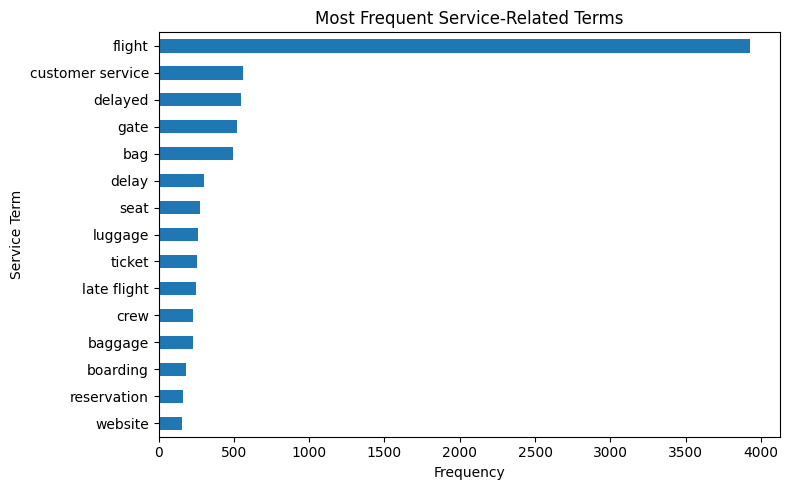

,count
service_term,
flight,3929
customer service,560
delayed,545
gate,518
bag,492
delay,300
seat,275
luggage,259
ticket,255


In [17]:
# Figure 7 — Service-term frequency detected by PhraseMatcher
if not service_terms_df.empty:
    service_counts = service_terms_df['service_term'].value_counts().head(15).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    service_counts.plot(kind='barh')
    plt.title('Most Frequent Service-Related Terms')
    plt.xlabel('Frequency')
    plt.ylabel('Service Term')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'task1_service_term_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()
    display(service_counts.sort_values(ascending=False).to_frame('count'))
else:
    print('No service terms available for plotting.')

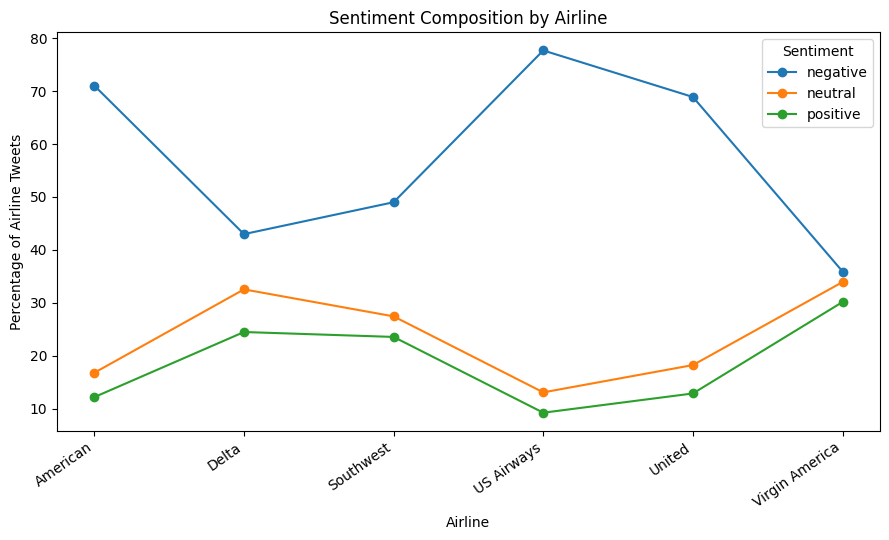

airline_sentiment,negative,neutral,positive
airline,,,
American,71.04,16.78,12.18
Delta,42.98,32.54,24.48
Southwest,49.01,27.44,23.55
US Airways,77.69,13.08,9.23
United,68.89,18.24,12.87
Virgin America,35.91,33.93,30.16


In [18]:
# Figure 8 — Sentiment composition by airline (row-normalised percentages)
airline_sentiment_pct = pd.crosstab(
    df['airline'], df['airline_sentiment'], normalize='index'
).reindex(columns=['negative', 'neutral', 'positive']) * 100

plt.figure(figsize=(9, 5.5))
for sentiment in airline_sentiment_pct.columns:
    plt.plot(airline_sentiment_pct.index, airline_sentiment_pct[sentiment], marker='o', label=sentiment)
plt.title('Sentiment Composition by Airline')
plt.xlabel('Airline')
plt.ylabel('Percentage of Airline Tweets')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_airline_sentiment_percentages.png', dpi=300, bbox_inches='tight')
plt.show()

display(airline_sentiment_pct.round(2))
airline_sentiment_pct.round(2).to_csv(TABLE_DIR / 'airline_sentiment_percentages.csv')

In [19]:
# Prepare labels and a stratified split
LABEL_ORDER = ['negative', 'neutral', 'positive']
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

df_model = df.loc[df['airline_sentiment'].isin(LABEL_ORDER)].copy()
df_model['label_id'] = df_model['airline_sentiment'].map(label_to_id)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    df_model['nltk_processed'],
    df_model['label_id'],
    df_model.index,
    test_size=0.20,
    random_state=SEED,
    stratify=df_model['label_id']
)

print('Training examples:', len(X_train))
print('Test examples:', len(X_test))
print('\nTraining class proportions:')
display(y_train.map(id_to_label).value_counts(normalize=True).rename('proportion').to_frame())
print('\nTest class proportions:')
display(y_test.map(id_to_label).value_counts(normalize=True).rename('proportion').to_frame())

Training examples: 11712
Test examples: 2928

Training class proportions:


,proportion
label_id,
negative,0.626964
neutral,0.211663
positive,0.161373



Test class proportions:


,proportion
label_id,
negative,0.626708
neutral,0.211749
positive,0.161544


In [20]:
# Reusable evaluation helper

def classification_metrics(y_true, y_pred, model_name, train_seconds=None):
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f_macro,
        'precision_weighted': p_weighted,
        'recall_weighted': r_weighted,
        'f1_weighted': f_weighted,
        'train_seconds': train_seconds
    }


def show_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(LABEL_ORDER)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format='d')
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


def report_dataframe(y_true, y_pred):
    report = classification_report(
        y_true, y_pred, labels=range(len(LABEL_ORDER)), target_names=LABEL_ORDER,
        output_dict=True, zero_division=0
    )
    return pd.DataFrame(report).T

In [21]:
# Model A — TF-IDF + Logistic Regression
logreg_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.98,
        sublinear_tf=True, max_features=50000
    )),
    ('clf', LogisticRegression(
        max_iter=1500, class_weight='balanced', random_state=SEED
    ))
])

start = time.perf_counter()
logreg_model.fit(X_train, y_train)
logreg_train_seconds = time.perf_counter() - start
logreg_pred = logreg_model.predict(X_test)

logreg_metrics = classification_metrics(
    y_test, logreg_pred, 'TF-IDF + Logistic Regression', logreg_train_seconds
)
print(f'Training time: {logreg_train_seconds:.2f} seconds')
display(pd.DataFrame([logreg_metrics]).round(4))

Training time: 4.88 seconds


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_seconds
0,TF-IDF + Logistic Regression,0.7698,0.7092,0.7334,0.7185,0.7866,0.7698,0.7757,4.8763


In [22]:
# Model B — TF-IDF + Linear SVM
svm_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.98,
        sublinear_tf=True, max_features=50000
    )),
    ('clf', LinearSVC(class_weight='balanced', random_state=SEED))
])

start = time.perf_counter()
svm_model.fit(X_train, y_train)
svm_train_seconds = time.perf_counter() - start
svm_pred = svm_model.predict(X_test)

svm_metrics = classification_metrics(
    y_test, svm_pred, 'TF-IDF + Linear SVM', svm_train_seconds
)
print(f'Training time: {svm_train_seconds:.2f} seconds')
display(pd.DataFrame([svm_metrics]).round(4))

Training time: 0.70 seconds


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_seconds
0,TF-IDF + Linear SVM,0.776,0.7171,0.7031,0.7095,0.7744,0.776,0.7749,0.6982


In [23]:
# Compare the classical models
classical_metrics_df = pd.DataFrame([logreg_metrics, svm_metrics]).sort_values('f1_macro', ascending=False)
display(classical_metrics_df.round(4))
classical_metrics_df.to_csv(TABLE_DIR / 'task2_classical_metrics.csv', index=False)

best_classical_name = classical_metrics_df.iloc[0]['model']
print('Best classical model by macro-F1:', best_classical_name)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_seconds
0,TF-IDF + Logistic Regression,0.7698,0.7092,0.7334,0.7185,0.7866,0.7698,0.7757,4.8763
1,TF-IDF + Linear SVM,0.7760,0.7171,0.7031,0.7095,0.7744,0.7760,0.7749,0.6982


Best classical model by macro-F1: TF-IDF + Logistic Regression


In [24]:
# Classification reports
logreg_report = report_dataframe(y_test, logreg_pred)
svm_report = report_dataframe(y_test, svm_pred)

print('Logistic Regression classification report')
display(logreg_report.round(4))
print('\nLinear SVM classification report')
display(svm_report.round(4))

logreg_report.to_csv(TABLE_DIR / 'task2_logreg_classification_report.csv')
svm_report.to_csv(TABLE_DIR / 'task2_svm_classification_report.csv')

Logistic Regression classification report


,precision,recall,f1-score,support
negative,0.8911,0.8158,0.8518,1835.0000
neutral,0.5656,0.6952,0.6237,620.0000
positive,0.6708,0.6892,0.6799,473.0000
accuracy,0.7698,0.7698,0.7698,0.7698
macro avg,0.7092,0.7334,0.7185,2928.0000
weighted avg,0.7866,0.7698,0.7757,2928.0000



Linear SVM classification report


,precision,recall,f1-score,support
negative,0.8542,0.8714,0.8627,1835.000
neutral,0.5885,0.5952,0.5918,620.000
positive,0.7086,0.6427,0.6741,473.000
accuracy,0.7760,0.7760,0.7760,0.776
macro avg,0.7171,0.7031,0.7095,2928.000
weighted avg,0.7744,0.7760,0.7749,2928.000


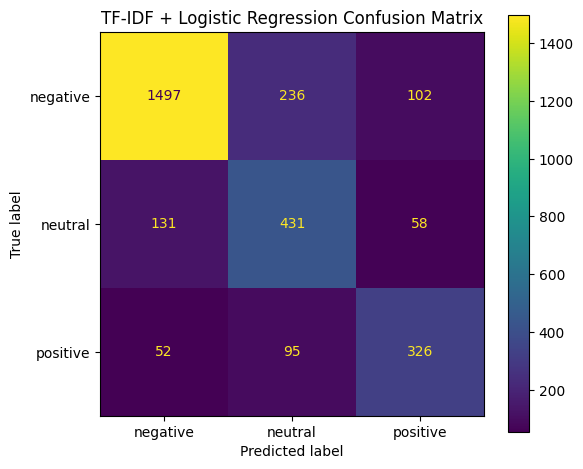

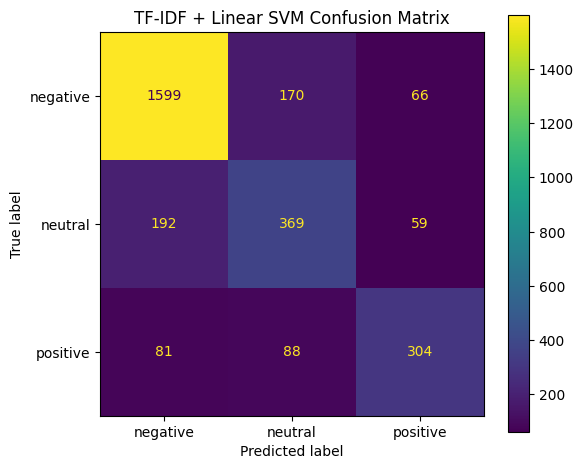

In [25]:
# Confusion matrices — saved as separate report-ready figures
show_confusion(
    y_test, logreg_pred,
    'TF-IDF + Logistic Regression Confusion Matrix',
    'task2_logreg_confusion_matrix.png'
)

show_confusion(
    y_test, svm_pred,
    'TF-IDF + Linear SVM Confusion Matrix',
    'task2_svm_confusion_matrix.png'
)

## 2.1 Misclassification analysis

The brief requires interpretation of at least two misclassified examples. The next cell extracts real mistakes from the better classical model. Select at least two informative rows from this table for the report and explain the linguistic reason for each error (e.g., sarcasm, mixed sentiment, implicit complaint, context dependency, very short text, annotation ambiguity).

In [26]:
# Extract real misclassified examples from the best classical model
if best_classical_name == 'TF-IDF + Linear SVM':
    best_pred = svm_pred
    best_model = svm_model
else:
    best_pred = logreg_pred
    best_model = logreg_model

error_rows = df_model.loc[idx_test, ['text', 'text_basic', 'nltk_processed', 'airline', 'airline_sentiment', 'negativereason']].copy()
error_rows['true_label'] = [id_to_label[int(v)] for v in y_test.to_numpy()]
error_rows['predicted_label'] = [id_to_label[int(v)] for v in best_pred]
error_rows['is_error'] = error_rows['true_label'] != error_rows['predicted_label']

misclassified_df = error_rows.loc[error_rows['is_error']].copy()
misclassified_df = misclassified_df[
    ['text', 'airline', 'negativereason', 'true_label', 'predicted_label', 'nltk_processed']
]

print('Total misclassified test examples:', len(misclassified_df))
display(misclassified_df.head(20))
misclassified_df.to_csv(TABLE_DIR / 'task2_misclassified_examples.csv', index=False)

Total misclassified test examples: 674


,text,airline,negativereason,true_label,predicted_label,nltk_processed
2998,@united past,United,NaN,neutral,negative,past
7719,@JetBlue would you say a delay is more likely?...,Delta,NaN,positive,negative,would say delay likely thanks much
4686,@SouthwestAir When will the flight resume? I d...,Southwest,Late Flight,negative,neutral,flight resume see open schedule
3838,@united of course but they were just as helple...,United,Flight Attendant Complaints,negative,positive,course helpless everyone else
8985,@USAirways Well I did miss it. But gate agents...,US Airways,NaN,positive,negative,well miss gate agent rebooked board pas wait l...
1281,@united wi-fi on 737-800 (aircraft 3511) didn'...,United,Bad Flight,negative,neutral,aircraft n't work entire flight morning
958,@united rarely ceases to amaze...for the worse...,United,Can't Tell,negative,positive,rarely cease amaze bad hope last time fly
6130,"@SouthwestAir My flight was 952, leaving las v...",Southwest,Bad Flight,negative,neutral,flight leave las vega arrive pm
5877,"@southwestair *any site*? gmail, facebook, etc.",Southwest,NaN,neutral,negative,site gmail facebook etc
7287,@JetBlue such a bummer. But I understand it's...,Delta,NaN,neutral,negative,bummer understand business deal thanks answer ...


## 2.2 Preprocessing ablation: with vs without stop-word removal/lemmatisation

This small ablation checks whether the chosen preprocessing materially changes a Logistic Regression baseline. It compares the NLTK processed text against lightly cleaned text where TF-IDF sees the original lexical forms and stop words. This directly supports the required reflection on preprocessing choices.

In [27]:
# Use the exact same row indices as the main split for a fair preprocessing comparison.
X_train_basic = df_model.loc[idx_train, 'text_basic']
X_test_basic = df_model.loc[idx_test, 'text_basic']
y_train_ab = df_model.loc[idx_train, 'label_id']
y_test_ab = df_model.loc[idx_test, 'label_id']

basic_text_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.98,
        sublinear_tf=True, max_features=50000
    )),
    ('clf', LogisticRegression(max_iter=1500, class_weight='balanced', random_state=SEED))
])

start = time.perf_counter()
basic_text_model.fit(X_train_basic, y_train_ab)
basic_train_seconds = time.perf_counter() - start
basic_pred = basic_text_model.predict(X_test_basic)

ablation_rows = [
    classification_metrics(y_test_ab, basic_pred, 'Light cleaning / no explicit stop-word removal', basic_train_seconds),
    logreg_metrics
]
ablation_df = pd.DataFrame(ablation_rows)[['model', 'accuracy', 'f1_macro', 'f1_weighted', 'train_seconds']]
display(ablation_df.round(4))
ablation_df.to_csv(TABLE_DIR / 'task2_preprocessing_ablation.csv', index=False)

,model,accuracy,f1_macro,f1_weighted,train_seconds
0,Light cleaning / no explicit stop-word removal,0.7893,0.7390,0.7931,5.6049
1,TF-IDF + Logistic Regression,0.7698,0.7185,0.7757,4.8763


In [28]:
from sentence_transformers import SentenceTransformer

# Use up to 6,000 stratified examples for efficient Colab retrieval/visualisation.
EMBEDDING_SAMPLE_SIZE = min(6000, len(df_model))
embedding_df, _ = train_test_split(
    df_model,
    train_size=EMBEDDING_SAMPLE_SIZE,
    random_state=SEED,
    stratify=df_model['label_id']
)
embedding_df = embedding_df.reset_index(drop=False).rename(columns={'index': 'source_index'})

embedding_model_name = 'sentence-transformers/all-MiniLM-L6-v2'
embedding_model = SentenceTransformer(embedding_model_name)

start = time.perf_counter()
embeddings = embedding_model.encode(
    embedding_df['text_basic'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
embedding_seconds = time.perf_counter() - start

print('Embedding sample size:', len(embedding_df))
print('Embedding matrix shape:', embeddings.shape)
print(f'Embedding generation time: {embedding_seconds:.2f} seconds')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding sample size: 6000
Embedding matrix shape: (6000, 384)
Embedding generation time: 5.66 seconds


## 3.1 Cosine-similarity retrieval

The function below embeds a new customer complaint and retrieves the most semantically similar feedback examples from the dataset.

In [29]:
def retrieve_similar_feedback(query, top_k=5):
    query_clean = basic_clean_text(query)
    query_vec = embedding_model.encode(
        [query_clean], convert_to_numpy=True, normalize_embeddings=True
    )
    scores = cosine_similarity(query_vec, embeddings)[0]
    top_positions = np.argsort(scores)[::-1][:top_k]

    result = embedding_df.iloc[top_positions][
        ['source_index', 'text', 'airline_sentiment', 'airline', 'negativereason']
    ].copy()
    result.insert(0, 'cosine_similarity', scores[top_positions])
    return result.reset_index(drop=True)


query = 'my flight was delayed for hours and customer service did not help'
retrieval_results = retrieve_similar_feedback(query, top_k=5)
print('Query:', query)
display(retrieval_results)
retrieval_results.to_csv(TABLE_DIR / 'task3_retrieval_example.csv', index=False)

Query: my flight was delayed for hours and customer service did not help


,cosine_similarity,source_index,text,airline_sentiment,airline,negativereason
0,0.743064,4483,@SouthwestAir can you tell me why you Cancelle...,negative,Southwest,Cancelled Flight
1,0.730419,13919,@AmericanAir just Cancelled Flightled my 7 am ...,negative,American,Cancelled Flight
2,0.727024,3067,@united can you help me with a delayed flight ...,negative,United,Late Flight
3,0.725875,10784,@USAirways I keep calling your help line (800)...,negative,US Airways,Customer Service Issue
4,0.717650,6689,@SouthwestAir disappointed with customer servi...,negative,Southwest,Customer Service Issue


In [30]:
# Additional retrieval queries to show semantic behaviour across different service issues
queries = [
    'my baggage was lost after the flight',
    'I need a refund because my booking was cancelled',
    'the staff were helpful and I had a great experience'
]

for q in queries:
    print('\nQUERY:', q)
    display(retrieve_similar_feedback(q, top_k=3))


QUERY: my baggage was lost after the flight


,cosine_similarity,source_index,text,airline_sentiment,airline,negativereason
0,0.778114,12287,@AmericanAir \nHello...My baggage has been los...,negative,American,Lost Luggage
1,0.746682,9829,@USAirways ...was Cancelled Flightled and now ...,negative,US Airways,Cancelled Flight
2,0.726435,2972,@united what do I do if something is missing f...,neutral,United,NaN



QUERY: I need a refund because my booking was cancelled


,cosine_similarity,source_index,text,airline_sentiment,airline,negativereason
0,0.717078,5399,@SouthwestAir - i needed refund on my Cancelle...,negative,Southwest,Cancelled Flight
1,0.716878,12885,@AmericanAir I Cancelled Flightled my ticket a...,negative,American,Customer Service Issue
2,0.715041,5388,@SouthwestAir How can we get refund instead of...,neutral,Southwest,NaN



QUERY: the staff were helpful and I had a great experience


,cosine_similarity,source_index,text,airline_sentiment,airline,negativereason
0,0.665890,2552,@united service by staff was great as usual. C...,positive,United,NaN
1,0.608327,144,@VirginAmerica you have amazing staff &amp; su...,positive,Virgin America,NaN
2,0.586797,14619,@AmericanAir I love your company and your staf...,positive,American,NaN


## 3.2 PCA visualisation of feedback embeddings

PCA projects a representative embedding sample to two dimensions. The plot does **not** prove that sentiment is perfectly separable; instead it provides an exploratory view of whether semantic structure and sentiment overlap are visible.

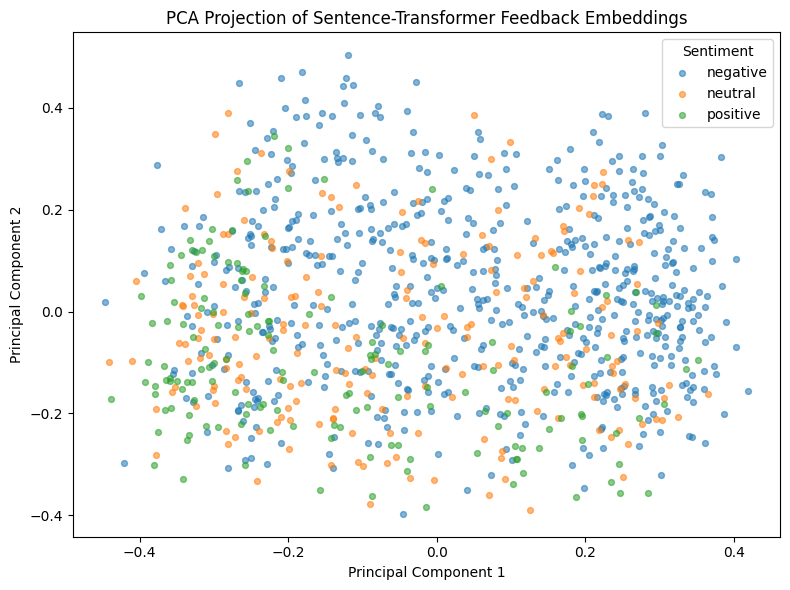

Explained variance ratio: [0.0601 0.039 ]


In [31]:
# PCA on a representative stratified subset for visual clarity
VIS_SAMPLE_SIZE = min(1000, len(embedding_df))
vis_df, _ = train_test_split(
    embedding_df,
    train_size=VIS_SAMPLE_SIZE,
    random_state=SEED,
    stratify=embedding_df['label_id']
)
vis_positions = vis_df.index.to_numpy()
vis_embeddings = embeddings[vis_positions]

pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(vis_embeddings)

plt.figure(figsize=(8, 6))
for sentiment in LABEL_ORDER:
    mask = vis_df['airline_sentiment'].to_numpy() == sentiment
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=18, alpha=0.55, label=sentiment)
plt.title('PCA Projection of Sentence-Transformer Feedback Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3_embedding_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_.round(4))

## 3.3 Optional t-SNE visualisation

t-SNE can reveal local neighbourhood structure that PCA may compress, but distances between distant clusters should not be over-interpreted. The sample is deliberately limited for speed and readability.

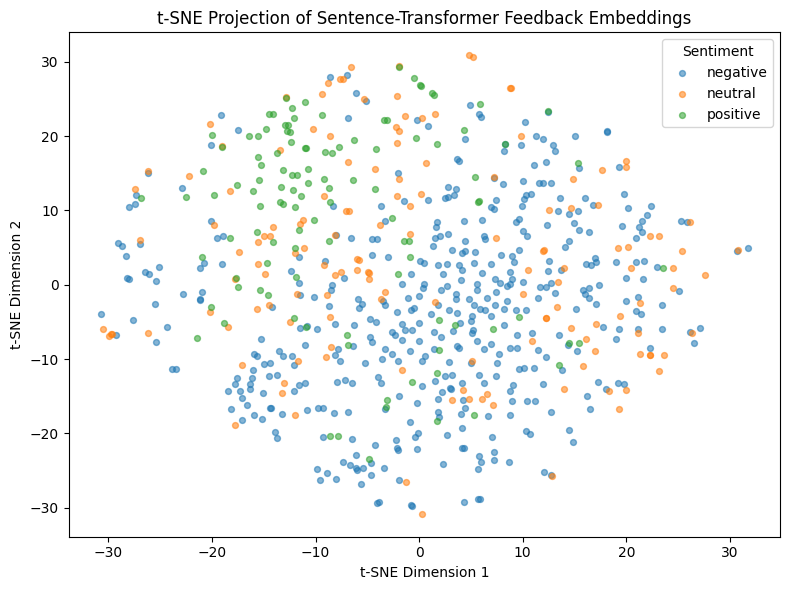

In [32]:
# t-SNE on a smaller subset to keep Colab runtime manageable
TSNE_SAMPLE_SIZE = min(700, len(embedding_df))
tsne_df, _ = train_test_split(
    embedding_df,
    train_size=TSNE_SAMPLE_SIZE,
    random_state=SEED,
    stratify=embedding_df['label_id']
)
tsne_positions = tsne_df.index.to_numpy()
tsne_embeddings = embeddings[tsne_positions]

perplexity = min(30, max(5, (TSNE_SAMPLE_SIZE - 1) // 10))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto',
    random_state=SEED
)
tsne_coords = tsne.fit_transform(tsne_embeddings)

plt.figure(figsize=(8, 6))
for sentiment in LABEL_ORDER:
    mask = tsne_df['airline_sentiment'].to_numpy() == sentiment
    plt.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1], s=18, alpha=0.55, label=sentiment)
plt.title('t-SNE Projection of Sentence-Transformer Feedback Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3_embedding_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

try:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [34]:
# Build a stratified transformer subset and a reproducible 80/20 split
TRANSFORMER_SAMPLE_SIZE = min(4500, len(df_model))
transformer_df, _ = train_test_split(
    df_model,
    train_size=TRANSFORMER_SAMPLE_SIZE,
    random_state=SEED,
    stratify=df_model['label_id']
)
transformer_df = transformer_df.copy()

tr_train, tr_test = train_test_split(
    transformer_df,
    test_size=0.20,
    random_state=SEED,
    stratify=transformer_df['label_id']
)

print('Transformer sample size:', len(transformer_df))
print('Train:', len(tr_train), 'Test:', len(tr_test))
print('\nTransformer subset class distribution:')
display(transformer_df['airline_sentiment'].value_counts().to_frame('count'))

Transformer sample size: 4500
Train: 3600 Test: 900

Transformer subset class distribution:


,count
airline_sentiment,
negative,2821
neutral,953
positive,726


In [35]:
# Tokeniser and PyTorch dataset
TRANSFORMER_MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 2
LEARNING_RATE = 2e-5

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

class TweetSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_dataset = TweetSentimentDataset(
    tr_train['text_basic'], tr_train['label_id'], tokenizer, MAX_LENGTH
)
test_dataset = TweetSentimentDataset(
    tr_test['text_basic'], tr_test['label_id'], tokenizer, MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Training batches:', len(train_loader))
print('Test batches:', len(test_loader))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training batches: 225
Test batches: 57


In [36]:
# Model, optimiser and scheduler
id2label_hf = {i: label for i, label in enumerate(LABEL_ORDER)}
label2id_hf = {label: i for i, label in enumerate(LABEL_ORDER)}

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    id2label=id2label_hf,
    label2id=label2id_hf
).to(device)

optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_steps)),
    num_training_steps=total_steps
)

transformer_parameter_count = sum(p.numel() for p in transformer_model.parameters())
print(f'Trainable model parameters: {transformer_parameter_count:,}')

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable model parameters: 66,955,779


In [37]:
# Evaluation helper for DistilBERT
@torch.no_grad()
def evaluate_transformer(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    losses = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        losses.append(float(outputs.loss.detach().cpu()))
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(batch['labels'].detach().cpu().numpy().tolist())

    metrics = classification_metrics(
        np.array(all_labels), np.array(all_preds), 'Fine-tuned DistilBERT'
    )
    metrics['loss'] = float(np.mean(losses)) if losses else np.nan
    return metrics, np.array(all_labels), np.array(all_preds)

print('Evaluation helper ready.')

Evaluation helper ready.


In [38]:
# Fine-tune DistilBERT
best_macro_f1 = -1.0
best_model_path = MODEL_DIR / 'best_distilbert'
history = []

start_training = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    transformer_model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, start=1):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        outputs = transformer_model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        running_loss += float(loss.detach().cpu())

        if step % 50 == 0 or step == len(train_loader):
            print(
                f'Epoch {epoch}/{EPOCHS} | step {step}/{len(train_loader)} '
                f'| mean train loss {running_loss / step:.4f}'
            )

    val_metrics, _, _ = evaluate_transformer(transformer_model, test_loader)
    epoch_row = {
        'epoch': epoch,
        'train_loss': running_loss / max(1, len(train_loader)),
        'validation_loss': val_metrics['loss'],
        'accuracy': val_metrics['accuracy'],
        'f1_macro': val_metrics['f1_macro'],
        'f1_weighted': val_metrics['f1_weighted']
    }
    history.append(epoch_row)
    print('Epoch evaluation:', {k: round(v, 4) if isinstance(v, float) else v for k, v in epoch_row.items()})

    if val_metrics['f1_macro'] > best_macro_f1:
        best_macro_f1 = val_metrics['f1_macro']
        best_model_path.mkdir(parents=True, exist_ok=True)
        transformer_model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print('Saved new best model to:', best_model_path)

transformer_train_seconds = time.perf_counter() - start_training
print(f'\nTotal DistilBERT training time: {transformer_train_seconds:.2f} seconds')

history_df = pd.DataFrame(history)
display(history_df.round(4))
history_df.to_csv(TABLE_DIR / 'task4_training_history.csv', index=False)

Epoch 1/2 | step 50/225 | mean train loss 0.9737
Epoch 1/2 | step 100/225 | mean train loss 0.8508
Epoch 1/2 | step 150/225 | mean train loss 0.7588
Epoch 1/2 | step 200/225 | mean train loss 0.6991
Epoch 1/2 | step 225/225 | mean train loss 0.6747
Epoch evaluation: {'epoch': 1, 'train_loss': 0.6747, 'validation_loss': 0.4618, 'accuracy': 0.82, 'f1_macro': 0.757, 'f1_weighted': 0.816}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best model to: /content/nlp_outputs/models/best_distilbert
Epoch 2/2 | step 50/225 | mean train loss 0.3987
Epoch 2/2 | step 100/225 | mean train loss 0.3818
Epoch 2/2 | step 150/225 | mean train loss 0.3784
Epoch 2/2 | step 200/225 | mean train loss 0.3812
Epoch 2/2 | step 225/225 | mean train loss 0.3763
Epoch evaluation: {'epoch': 2, 'train_loss': 0.3763, 'validation_loss': 0.4457, 'accuracy': 0.8278, 'f1_macro': 0.7703, 'f1_weighted': 0.8232}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best model to: /content/nlp_outputs/models/best_distilbert

Total DistilBERT training time: 96.27 seconds


,epoch,train_loss,validation_loss,accuracy,f1_macro,f1_weighted
0,1,0.6747,0.4618,0.8200,0.7570,0.8160
1,2,0.3763,0.4457,0.8278,0.7703,0.8232


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_seconds,loss
0,Fine-tuned DistilBERT,0.8278,0.7902,0.7546,0.7703,0.8218,0.8278,0.8232,96.2712,0.4457


DistilBERT classification report


,precision,recall,f1-score,support
negative,0.8690,0.9291,0.8980,564.0000
neutral,0.6909,0.5969,0.6404,191.0000
positive,0.8106,0.7379,0.7726,145.0000
accuracy,0.8278,0.8278,0.8278,0.8278
macro avg,0.7902,0.7546,0.7703,900.0000
weighted avg,0.8218,0.8278,0.8232,900.0000


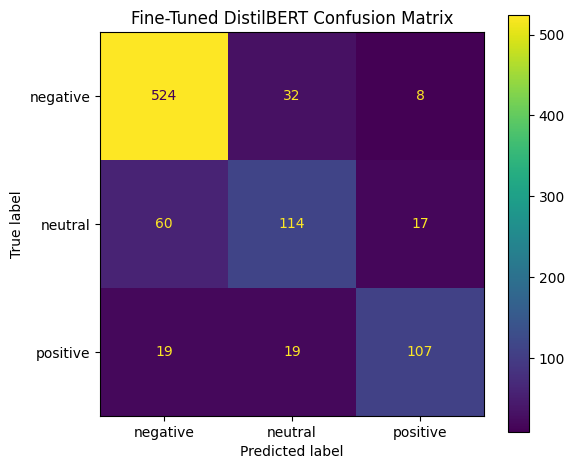

In [39]:
# Reload best checkpoint and produce final test predictions
transformer_model = AutoModelForSequenceClassification.from_pretrained(best_model_path).to(device)
transformer_metrics, transformer_y_true, transformer_y_pred = evaluate_transformer(transformer_model, test_loader)
transformer_metrics['train_seconds'] = transformer_train_seconds

transformer_metrics_df = pd.DataFrame([transformer_metrics])
display(transformer_metrics_df.round(4))
transformer_metrics_df.to_csv(TABLE_DIR / 'task4_transformer_metrics.csv', index=False)

transformer_report = report_dataframe(transformer_y_true, transformer_y_pred)
print('DistilBERT classification report')
display(transformer_report.round(4))
transformer_report.to_csv(TABLE_DIR / 'task4_distilbert_classification_report.csv')

show_confusion(
    transformer_y_true,
    transformer_y_pred,
    'Fine-Tuned DistilBERT Confusion Matrix',
    'task4_distilbert_confusion_matrix.png'
)

## 4.1 Transformer misclassification analysis

As with the classical model, inspect real DistilBERT errors. These examples are useful for discussing sarcasm, mixed sentiment, ambiguous short messages, label noise and context dependence.

In [40]:
transformer_error_df = tr_test[['text', 'airline', 'negativereason', 'airline_sentiment']].copy().reset_index(drop=False)
transformer_error_df['true_label'] = [id_to_label[int(v)] for v in transformer_y_true]
transformer_error_df['predicted_label'] = [id_to_label[int(v)] for v in transformer_y_pred]
transformer_error_df['is_error'] = transformer_error_df['true_label'] != transformer_error_df['predicted_label']

transformer_misclassified = transformer_error_df.loc[transformer_error_df['is_error']].copy()
print('Total DistilBERT errors:', len(transformer_misclassified))
display(transformer_misclassified.head(20))
transformer_misclassified.to_csv(TABLE_DIR / 'task4_distilbert_misclassified_examples.csv', index=False)

Total DistilBERT errors: 155


,index,text,airline,negativereason,airline_sentiment,true_label,predicted_label,is_error
16,7177,@JetBlue The chairs could use some TLC. And mo...,Delta,NaN,positive,positive,neutral,True
18,538,@united @CheerTymeDad Gee that's like almost c...,United,NaN,neutral,neutral,negative,True
21,13096,@AmericanAir due to road conditions,American,NaN,neutral,neutral,negative,True
25,714,@united how we looking on getting those bags t...,United,Lost Luggage,negative,negative,neutral,True
33,12849,@AmericanAir No snow in St. Louis. Cold but no...,American,NaN,neutral,neutral,negative,True
34,13271,@AmericanAir Lost black wallet at #DallasAirpo...,American,NaN,neutral,neutral,negative,True
36,11797,@USAirways please hold 3923! I can see it. Jus...,US Airways,NaN,neutral,neutral,negative,True
45,3711,@united's in-flight promo on their TV's includ...,United,NaN,neutral,neutral,negative,True
56,8873,@JetBlue I applied for a job at PDW where coul...,Delta,NaN,neutral,neutral,positive,True
58,41,"@VirginAmerica Hey, first time flyer next week...",Virgin America,Flight Booking Problems,negative,negative,neutral,True


## 4.2 Fair comparison with the classical baseline

A direct performance comparison is most defensible when both systems are evaluated on the **same examples**. Therefore, the cell below trains TF-IDF + Linear SVM on exactly `tr_train` and evaluates it on exactly `tr_test`.

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_seconds
0,"TF-IDF + Linear SVM (same 4,500-sample split)",0.7378,0.6633,0.6586,0.6609,0.7371,0.7378,0.7374,0.3079


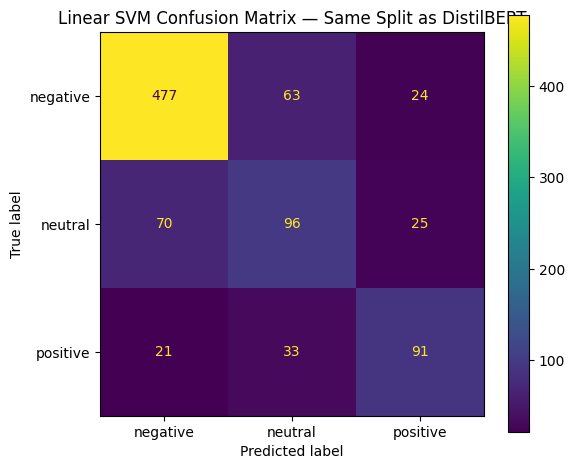

In [41]:
# Re-train Linear SVM on the exact transformer split
fair_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.98,
        sublinear_tf=True, max_features=50000
    )),
    ('clf', LinearSVC(class_weight='balanced', random_state=SEED))
])

start = time.perf_counter()
fair_svm.fit(tr_train['nltk_processed'], tr_train['label_id'])
fair_svm_seconds = time.perf_counter() - start
fair_svm_pred = fair_svm.predict(tr_test['nltk_processed'])

fair_svm_metrics = classification_metrics(
    tr_test['label_id'].to_numpy(), fair_svm_pred,
    'TF-IDF + Linear SVM (same 4,500-sample split)', fair_svm_seconds
)

display(pd.DataFrame([fair_svm_metrics]).round(4))
show_confusion(
    tr_test['label_id'].to_numpy(), fair_svm_pred,
    'Linear SVM Confusion Matrix — Same Split as DistilBERT',
    'task4_fair_svm_confusion_matrix.png'
)

In [42]:
# Quantitative comparison table
transformer_comparison_metrics = transformer_metrics.copy()
transformer_comparison_metrics['model'] = 'Fine-tuned DistilBERT'

quant_comparison = pd.DataFrame([
    fair_svm_metrics,
    transformer_comparison_metrics
])[
    ['model', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
     'f1_weighted', 'train_seconds']
]

display(quant_comparison.round(4))
quant_comparison.to_csv(TABLE_DIR / 'task4_quantitative_model_comparison.csv', index=False)

# Practical comparison required by the brief
svm_feature_count = len(fair_svm.named_steps['tfidf'].get_feature_names_out())
svm_coefficient_count = int(np.prod(fair_svm.named_steps['clf'].coef_.shape))

practical_comparison = pd.DataFrame([
    {
        'Criterion': 'Representation / model size',
        'TF-IDF + Linear SVM': f'{svm_feature_count:,} TF-IDF features; {svm_coefficient_count:,} linear coefficients',
        'Fine-tuned DistilBERT': f'{transformer_parameter_count:,} neural parameters'
    },
    {
        'Criterion': 'Training time on this run',
        'TF-IDF + Linear SVM': f'{fair_svm_seconds:.2f} seconds',
        'Fine-tuned DistilBERT': f'{transformer_train_seconds:.2f} seconds'
    },
    {
        'Criterion': 'Interpretability',
        'TF-IDF + Linear SVM': 'Relatively high: feature weights and n-grams can be inspected.',
        'Fine-tuned DistilBERT': 'Lower: contextual representations are harder to explain without extra XAI methods.'
    },
    {
        'Criterion': 'Resource requirements',
        'TF-IDF + Linear SVM': 'Low; practical on CPU with modest memory.',
        'Fine-tuned DistilBERT': 'Higher; GPU is preferable for training and inference costs are larger.'
    },
    {
        'Criterion': 'Context handling',
        'TF-IDF + Linear SVM': 'Sparse lexical patterns; limited contextual understanding.',
        'Fine-tuned DistilBERT': 'Contextual token representations can capture more semantic interactions.'
    },
    {
        'Criterion': 'Deployment practicality',
        'TF-IDF + Linear SVM': 'Simple, fast and inexpensive for high-volume routing.',
        'Fine-tuned DistilBERT': 'Potentially stronger accuracy/F1 but requires more monitoring, compute and optimisation.'
    }
])

display(practical_comparison)
practical_comparison.to_csv(TABLE_DIR / 'task4_practical_model_comparison.csv', index=False)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,train_seconds
0,"TF-IDF + Linear SVM (same 4,500-sample split)",0.7378,0.6633,0.6586,0.6609,0.7374,0.3079
1,Fine-tuned DistilBERT,0.8278,0.7902,0.7546,0.7703,0.8232,96.2712


,Criterion,TF-IDF + Linear SVM,Fine-tuned DistilBERT
0,Representation / model size,"4,537 TF-IDF features; 13,611 linear coefficients","66,955,779 neural parameters"
1,Training time on this run,0.31 seconds,96.27 seconds
2,Interpretability,Relatively high: feature weights and n-grams c...,Lower: contextual representations are harder t...
3,Resource requirements,Low; practical on CPU with modest memory.,Higher; GPU is preferable for training and inf...
4,Context handling,Sparse lexical patterns; limited contextual un...,Contextual token representations can capture m...
5,Deployment practicality,"Simple, fast and inexpensive for high-volume r...",Potentially stronger accuracy/F1 but requires ...


In [43]:
# Save an experiment manifest for reproducibility
manifest = {
    'random_seed': SEED,
    'dataset_rows': int(len(df)),
    'dataset_columns': int(df.shape[1]),
    'labels': LABEL_ORDER,
    'task2_test_fraction': 0.20,
    'embedding_model': embedding_model_name,
    'embedding_sample_size': int(EMBEDDING_SAMPLE_SIZE),
    'transformer_model': TRANSFORMER_MODEL_NAME,
    'transformer_sample_size': int(TRANSFORMER_SAMPLE_SIZE),
    'transformer_epochs': EPOCHS,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'device': str(device)
}

with open(OUTPUT_DIR / 'experiment_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

# Create a lightweight evidence ZIP containing report-ready figures, tables and the manifest.
# The trained transformer checkpoint remains in /content/nlp_outputs/models/ but is not
# included here because it can make the ZIP hundreds of MB.
evidence_dir = Path('/content/nlp_evidence_export')
if evidence_dir.exists():
    shutil.rmtree(evidence_dir)
evidence_dir.mkdir(parents=True)
shutil.copytree(FIG_DIR, evidence_dir / 'figures')
shutil.copytree(TABLE_DIR, evidence_dir / 'tables')
shutil.copy2(OUTPUT_DIR / 'experiment_manifest.json', evidence_dir / 'experiment_manifest.json')
zip_path = shutil.make_archive('/content/nlp_outputs_complete', 'zip', root_dir=evidence_dir)

print('Created lightweight evidence archive:', zip_path)
print('Best transformer checkpoint remains at:', best_model_path)
print('\nSaved report evidence:')
for path in sorted(evidence_dir.rglob('*')):
    if path.is_file():
        print('-', path.relative_to(evidence_dir))

Created lightweight evidence archive: /content/nlp_outputs_complete.zip
Best transformer checkpoint remains at: /content/nlp_outputs/models/best_distilbert

Saved report evidence:
- experiment_manifest.json
- figures/task1_airline_sentiment_percentages.png
- figures/task1_entity_type_frequency.png
- figures/task1_negative_reasons.png
- figures/task1_review_length_distribution.png
- figures/task1_sentiment_distribution.png
- figures/task1_service_term_frequency.png
- figures/task1_top_tokens.png
- figures/task1_wordcloud.png
- figures/task2_logreg_confusion_matrix.png
- figures/task2_svm_confusion_matrix.png
- figures/task3_embedding_pca.png
- figures/task3_embedding_tsne.png
- figures/task4_distilbert_confusion_matrix.png
- figures/task4_fair_svm_confusion_matrix.png
- tables/airline_sentiment_percentages.csv
- tables/dataset_missingness.csv
- tables/nltk_vs_spacy_comparison.csv
- tables/sentiment_counts.csv
- tables/service_terms.csv
- tables/spacy_entities.csv
- tables/task2_classica

In [44]:
# Optional Colab download of all generated technical evidence.
try:
    from google.colab import files
    files.download('/content/nlp_outputs_complete.zip')
except ImportError:
    print('Download helper is only available in Google Colab.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>